In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange, interp1d
import sympy as sp

In [2]:
# ── 1. SCHÉMAS LINÉAIRES OPTIMISÉS (BIBLIOTHÈQUES) ──────────────────────────


In [3]:
def schema_jacobi(A, b, x):
    """Version vectorisée avec NumPy (plus rapide que sum())"""
    D = np.diag(A)
    R = A - np.diagflat(D)
    # x_new = (b - R*x) / D
    return (b - np.dot(R, x)) / D

In [4]:
def schema_relaxation(A, b, x, omega):
    """Gauss-Seidel si omega=1. Utilise np.dot pour les sommes partielles."""
    n = len(b)
    x_new = x.copy()
    i = 0
    while i < n:
        # s1 : éléments déjà mis à jour, s2 : anciens éléments
        s1 = np.dot(A[i, :i], x_new[:i])
        s2 = np.dot(A[i, i+1:], x[i+1:])
        
        xgs = (b[i] - s1 - s2) / A[i, i]
        x_new[i] = (1 - omega) * x[i] + omega * xgs
        i += 1
    return x_new

In [5]:
# ── 2. ALGORITHME GÉNÉRAL DE CONVERGENCE ──────────────────────────────────────

def algorithme_general(A, b, x0, epsilon, nbItmax, schema_func, *args):
    x = x0.copy()
    nb = 0
    err = float('inf')
    start = time.perf_counter()
    
    while err > epsilon and nb < nbItmax:
        x_new = schema_func(A, b, x, *args)
        err = np.linalg.norm(x_new - x, ord=np.inf)
        x = x_new
        nb += 1
        
    end = time.perf_counter()
    t_exec = (end - start) * 1e6  # Temps en microsecondes
    return x, nb, t_exec

Solution finale Jacobi : [ 1.04326923  2.26923077 -1.08173077]
Solution finale Gauss-seidel : [ 1.04326923  2.26923077 -1.08173077]
Solution finale Relaxation : [ 1.04326923  2.26923077 -1.08173077]


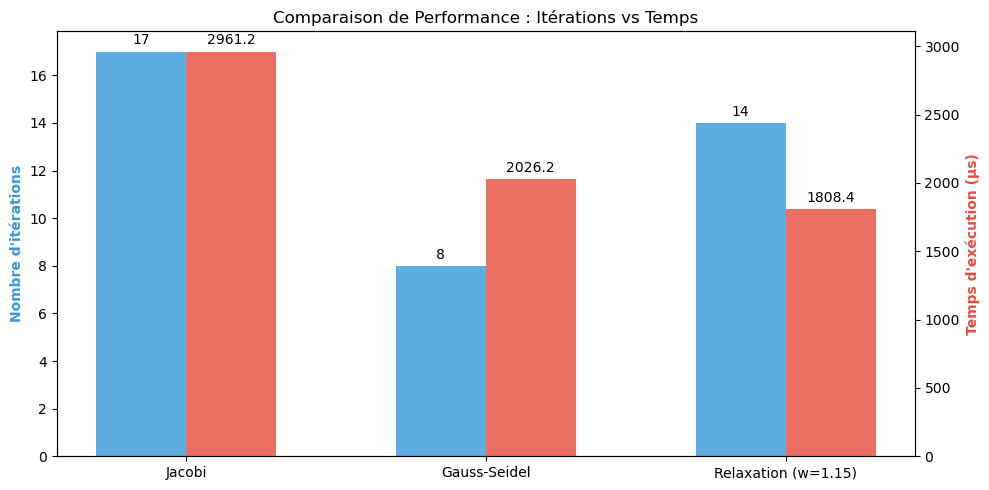

In [6]:
# ── 4. PROGRAMME PRINCIPAL ET GRAPHES ─────────────────────────────────────────

# --- Données de test ---
A = np.array([[10., -1., 2.], [-1., 11., -1.], [2., -1., 10.]])
b = np.array([6., 25., -11.])
x0 = np.array([0., 0., 0.])
eps = 1e-9
it_max = 500
w_opt = 1.15

# --- Calculs Performance ---
res_j = algorithme_general(A, b, x0, eps, it_max, schema_jacobi)
res_gs = algorithme_general(A, b, x0, eps, it_max, schema_relaxation, 1.0)
res_rel = algorithme_general(A, b, x0, eps, it_max, schema_relaxation, w_opt)

# --- Graphique 1 : Comparaison de Performance ---
methodes = ['Jacobi', 'Gauss-Seidel', f'Relaxation (w={w_opt})']
iters = [res_j[1], res_gs[1], res_rel[1]]
temps = [res_j[2], res_gs[2], res_rel[2]]

fig, ax1 = plt.subplots(figsize=(10, 5))
x_idx = np.arange(len(methodes))
width = 0.3

print(f"Solution finale Jacobi : {res_j[0]}")
print(f"Solution finale Gauss-seidel : {res_gs[0]}")
print(f"Solution finale Relaxation : {res_rel[0]}")

bar1 = ax1.bar(x_idx - width/2, iters, width, label='Itérations', color='#3498db', alpha=0.8)
ax1.set_ylabel('Nombre d\'itérations', color='#3498db', fontweight='bold')
ax1.set_xticks(x_idx)
ax1.set_xticklabels(methodes)

ax2 = ax1.twinx()
bar2 = ax2.bar(x_idx + width/2, temps, width, label='Temps (µs)', color='#e74c3c', alpha=0.8)
ax2.set_ylabel('Temps d\'exécution (µs)', color='#e74c3c', fontweight='bold')

plt.title("Comparaison de Performance : Itérations vs Temps")
ax1.bar_label(bar1, padding=3); ax2.bar_label(bar2, padding=3)
plt.tight_layout()
plt.show()

In [7]:
# ── 3. INTERPOLATION (SCIPY) ──────────────────────────────────────────────────

def comparer_interpolation(x_pts, y_pts):
    # Lagrange via SciPy 
    poly_lagrange = lagrange(x_pts, y_pts)
    
    # Spline Quadratique via SciPy
    f_spline = interp1d(x_pts, y_pts, kind='quadratic')
    
    return poly_lagrange, f_spline

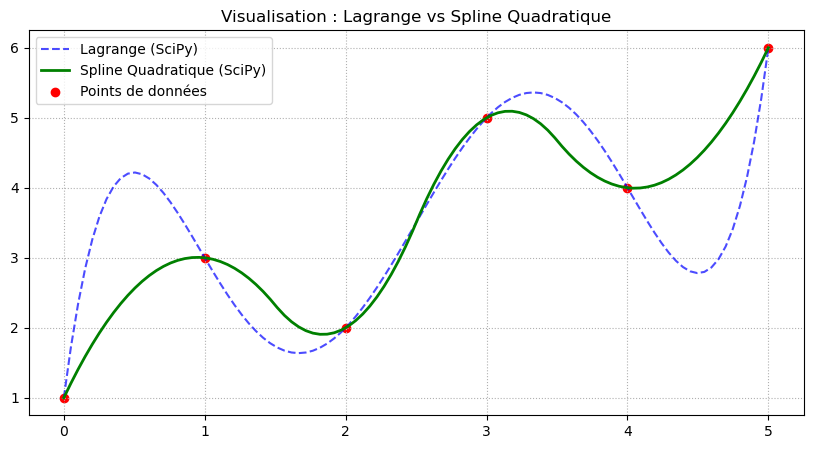

In [8]:


# --- Graphique 2 : Interpolation ---
x_p = np.array([0, 1, 2, 3, 4, 5])
y_p = np.array([1, 3, 2, 5, 4, 6]) # Données en zigzag pour voir la différence

p_lag, f_spl = comparer_interpolation(x_p, y_p)
x_fine = np.linspace(0, 5, 100)
p_lag_sp=p_lag(x_fine)
f_spl_sp=f_spl(x_fine)


plt.figure(figsize=(10, 5))
plt.plot(x_fine, p_lag_sp, 'b--', label='Lagrange (SciPy)', alpha=0.7)
plt.plot(x_fine, f_spl_sp, 'g-', label='Spline Quadratique (SciPy)', linewidth=2)
plt.scatter(x_p, y_p, color='red', label='Points de données')
    
plt.title("Visualisation : Lagrange vs Spline Quadratique")
plt.legend(); plt.grid(True, linestyle=':')
plt.show()


In [9]:
def construire_interpolation_sympy(x_pts, y_pts):
    """
    Version corrigée : Utilise sp.interpolate pour Lagrange 
    et sp.interpolating_spline pour la spline.
    """
    x = sp.Symbol('x')
    
    # --- 1. Construction du Polynôme de Lagrange (Version corrigée) ---
    # On crée une liste de couples (x, y) car c'est ce que sp.interpolate attend
    points = list(zip(x_pts, y_pts))
    
    # sp.interpolate(points, variable) calcule automatiquement le polynôme de Lagrange
    poly_lagrange = sp.interpolate(points, x)
    
    # --- 2. Construction de la Spline Quadratique ---
    # Note : On s'assure que x_pts et y_pts sont des listes standards pour SymPy
    spline_expr = sp.interpolating_spline(2, x, list(x_pts), list(y_pts))
    
    return x, sp.simplify(poly_lagrange), spline_expr

In [10]:
# 1. On récupère le symbole 'x' et les deux expressions mathématiques
x_sym, expr_lag, expr_spl = construire_interpolation_sympy(x_p, y_p)
    
# =========================================================================
# LA DÉMONSTRATION DE TES FONCTIONS (.subs, .evalf, lambdify)
# =========================================================================
    
valeur_test = 2.5
    
print(f"\nÉvaluation au point précis X = {valeur_test} :")

sp.pprint(expr_spl) # Affiche joliment les conditions (if/else) dans la console

# A. Substitution exacte (.subs)
lag_exact = expr_lag.subs(x_sym, valeur_test)
spl_exact = expr_spl.subs(x_sym, valeur_test)
print(f"-> Lagrange exact (.subs) : {lag_exact}")
#print(f"-> Spline  exact (.subs) : {expr_spl}")
    
# B. Évaluation décimale (.evalf)
lag_dec = lag_exact.evalf(5) # 5 chiffres après la virgule
spl_dec = spl_exact.evalf(5)
print(f"-> Lagrange décimal (.evalf) : {lag_dec}")
print(f"-> Spline décimal (.evalf)   : {spl_dec}")

# C. Création des fonctions rapides pour le graphique (lambdify)
# Transforme l'équation lente SymPy en fonction NumPy ultra-rapide
f_lag_rapide = sp.lambdify(x_sym, expr_lag, 'numpy')
f_spl_rapide = sp.lambdify(x_sym, expr_spl, 'numpy')
# =========================================================================
    
# --- Graphique 2 : Interpolation (Grâce à lambdify) ---
# Génération de 100 points pour tracer une courbe lisse
x_fine = np.linspace(0, 5, 100)
    
# L'évaluation massive se fait ici, de manière transparente grâce à lambdify
y_lag_fine = f_lag_rapide(x_fine)
y_spl_fine = f_spl_rapide(x_fine)


Évaluation au point précis X = 2.5 :
x
-> Lagrange exact (.subs) : 3.49999999999999
-> Lagrange décimal (.evalf) : 3.5000
-> Spline décimal (.evalf)   : 3.5000


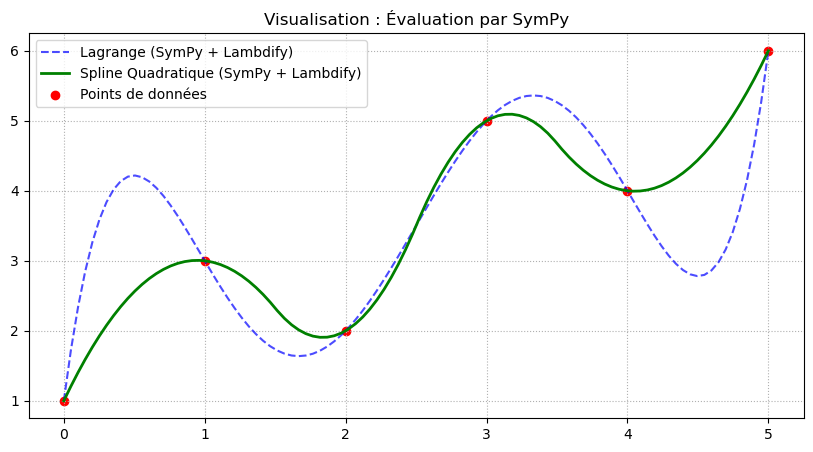

In [11]:


plt.figure(figsize=(10, 5))
plt.plot(x_fine, y_lag_fine, 'b--', label='Lagrange (SymPy + Lambdify)', alpha=0.7)
plt.plot(x_fine, y_spl_fine, 'g-', label='Spline Quadratique (SymPy + Lambdify)', linewidth=2)
plt.scatter(x_p, y_p, color='red', label='Points de données')
    
plt.title("Visualisation : Évaluation par SymPy")
plt.legend(); plt.grid(True, linestyle=':')
plt.show()
